# Phase 6 — Statistical Forecasting (ARIMA / SARIMA)
### Energy Demand Forecasting Project

**Question this phase answers:** can a classical statistical model beat the
Phase 5 baseline bar (daily seasonal naive: MAE 0.530, RMSE 0.786) at the
24-hour-ahead horizon?

Two models fit here, deliberately, for comparison:
- **Plain ARIMA** (no seasonal component) — isolates how much value the
  seasonal term actually adds.
- **SARIMA with m=24** (daily seasonality) — m=168 (weekly) is computationally
  intractable with statsmodels' state-space implementation, and Phase 5
  already showed daily lag beats weekly lag as a plain baseline, so this
  isn't just a shortcut.

Same shared train/test split and forecast origins as Phase 5, so the
comparison is fair.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
import mlflow
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import get_forecast_origins, compute_metrics, HORIZON
from src.evaluation.results_store import save_results
from src.models.sarima import stationarity_tests, fit_model, rolling_backtest

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


## Load data and reuse the shared Phase 5 split

In [3]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
con.close()

hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"]

test_start = get_train_test_split(series, test_frac=0.2)
train = series.loc[:test_start]
origins = get_forecast_origins(series, test_start, horizon=HORIZON)

print(f"Test starts: {test_start} | Train hours: {len(train):,} | Origins: {len(origins)}")


Test starts: 2010-02-11 00:00:00 | Train hours: 27,656 | Origins: 288


## Stationarity testing (ADF & KPSS)

Testing the raw training series, then the first difference, to decide the
differencing order `d`.


In [4]:
print("=== Raw series ===")
stationarity_tests(train)

print("\n=== First difference ===")
stationarity_tests(train.diff().dropna())


=== Raw series ===


/Users/apple/Documents/Projects/energy-demand-forecast/src/models/sarima.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, nlags="auto")


ADF:  statistic=-12.6028, p-value=0.0000 (stationary per ADF)
KPSS: statistic=1.0624, p-value=0.0100 (non-stationary per KPSS)

=== First difference ===
ADF:  statistic=-37.6491, p-value=0.0000 (stationary per ADF)
KPSS: statistic=0.0227, p-value=0.1000 (stationary per KPSS)


/Users/apple/Documents/Projects/energy-demand-forecast/src/models/sarima.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, nlags="auto")


{'adf_statistic': np.float64(-37.64914482916983),
 'adf_pvalue': 0.0,
 'kpss_statistic': np.float64(0.022745607605818154),
 'kpss_pvalue': np.float64(0.1)}

## ACF / PACF at hourly grain

Zoomed to 72 lags (3 days) to clearly see the daily spike at lag 24 (and 48)
that the seasonal term needs to capture.


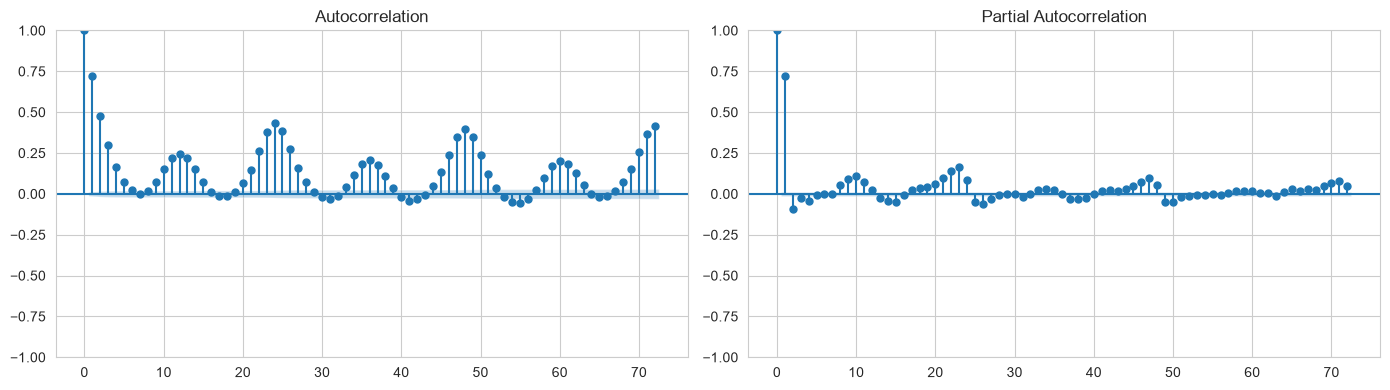

In [5]:
train_filled = train.interpolate(limit_direction="both")  # ACF/PACF plotting needs no NaNs

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_filled, lags=72, ax=axes[0])
plot_pacf(train_filled, lags=72, ax=axes[1])
plt.tight_layout()
plt.show()


## Order search (auto_arima)

**Assumption flagged:** running `auto_arima` on the full ~27,600-hour
training set with seasonal m=24 would be extremely slow. Searching on the
most recent 60 days (1,440 hours) instead -- recent data is what matters
most for a model that only captures daily seasonality (no long-term trend
was found in Phase 2 anyway). `auto_arima` requires complete data for its
search, so this subset is interpolated -- this interpolation is ONLY for the
search step, not for the final model fit below.


In [6]:
search_subset = train.iloc[-1440:].interpolate(limit_direction="both")

auto_model = pm.auto_arima(
    search_subset,
    seasonal=True, m=24,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    d=None, D=None,
    stepwise=True, trace=True,
    error_action="ignore", suppress_warnings=True,
)
print(auto_model.summary())

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f"\nSelected order: {order}, seasonal_order: {seasonal_order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=4.98 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=3124.081, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=3021.336, Time=0.58 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=3044.265, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=3122.081, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=3121.876, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=2980.054, Time=3.00 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=14.61 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(0,1,0)(2,0,0)[24] intercept   : AIC=3004.937, Time=2.11 sec
 ARIMA(2,1,0)(2,0,0)[24] intercept   : AIC=2948.680, Time=3.68 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=2996.581, Time=0.68 sec
 ARIMA(2,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=17.42 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.75 sec
 ARIMA(3,1,0)(2,0,0)[24] intercept   : AIC

## Fit final ARIMA and SARIMA models

**Assumption flagged:** fitting on the most recent ~6 months of training
data (4,380 hours), not the full 4 years -- SARIMA with m=24 only models
daily seasonality, so multi-year history adds fitting cost without adding
relevant signal (no long-term trend was found in Phase 2 either). This means
neither model captures annual seasonality -- a real limitation, worth
carrying into the model comparison discussion in Phase 9.

Passed directly to statsmodels (not interpolated) -- the Kalman filter
handles the known data gaps as missing observations natively.


In [7]:
fit_window = train.iloc[-4380:]
print(f"Fitting on {len(fit_window):,} hours: {fit_window.index.min()} to {fit_window.index.max()}")

arima_fit = fit_model(fit_window, order=order, seasonal_order=(0, 0, 0, 0))
sarima_fit = fit_model(fit_window, order=order, seasonal_order=seasonal_order)

print(f"\nARIMA AIC: {arima_fit.aic:.1f}")
print(f"SARIMA AIC: {sarima_fit.aic:.1f}")


Fitting on 4,380 hours: 2009-08-12 13:00:00 to 2010-02-11 00:00:00


/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates


ARIMA AIC: 8994.5
SARIMA AIC: 8531.4


## Residual diagnostics (SARIMA)

Four-panel diagnostic: standardized residuals over time, histogram vs normal
density, Q-Q plot, and residual correlogram. Plus an explicit Ljung-Box test
for residual autocorrelation (null: residuals are white noise -- a good
model's residuals should NOT be significantly autocorrelated).


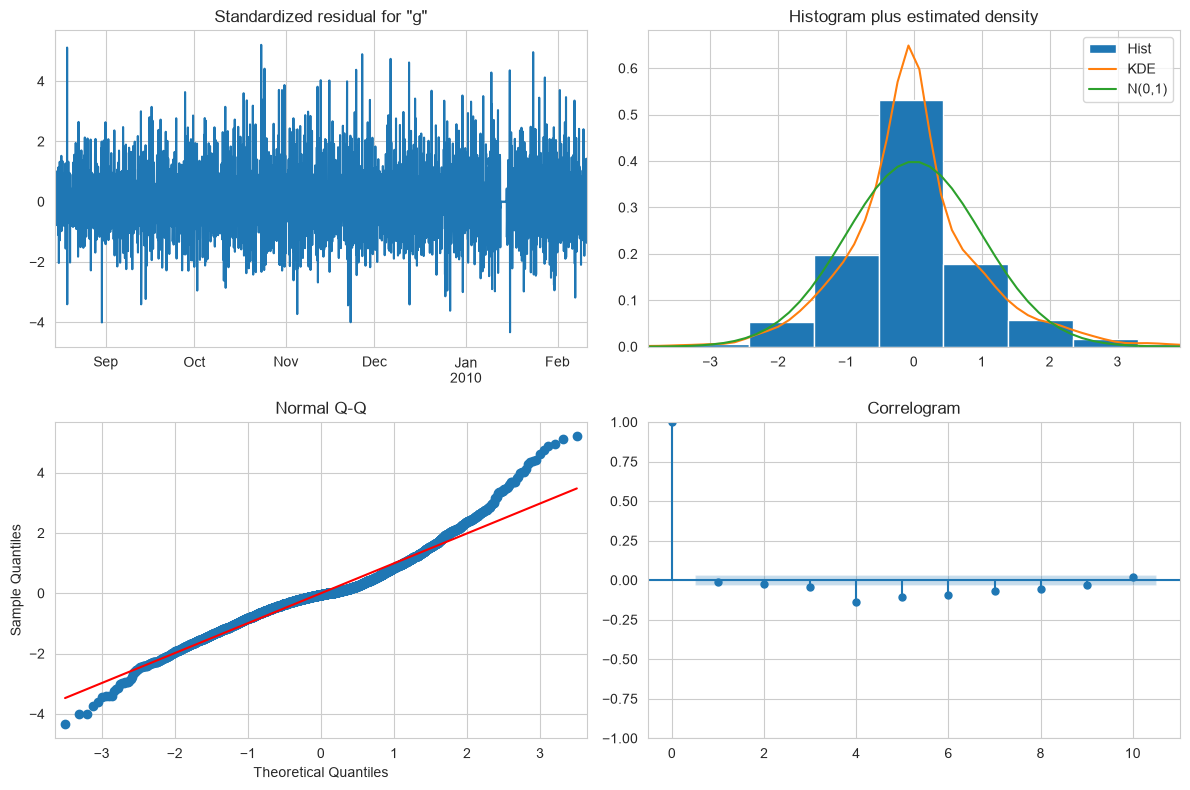

       lb_stat     lb_pvalue
24  214.078297  1.922606e-32
48  343.111045  3.429789e-46


In [8]:
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(sarima_fit.resid.dropna(), lags=[24, 48], return_df=True)
print(lb_test)


## Rolling-origin backtest

Both models walk forward through every test-period origin using
`.append(refit=False)` -- parameters stay fixed after the initial fit above;
only the model's internal state is kept current with new observations.


In [9]:
arima_results = rolling_backtest(series, arima_fit, origins, HORIZON, "arima")
sarima_results = rolling_backtest(series, sarima_fit, origins, HORIZON, "sarima")

combined_results = pd.concat([arima_results, sarima_results], ignore_index=True)
combined_results.head()


ValueError: Given `endog` does not have an index that extends the index of the model. Expected index frequency is "<Hour>", but got "None".

## Metrics vs. the Phase 5 baseline

In [ ]:
summary = {}
for name in ["arima", "sarima"]:
    summary[name] = compute_metrics(combined_results[combined_results["method"] == name])

# Hardcoded from Phase 5 findings (results weren't persisted at the time) --
# if you added the retroactive save_results() cell to notebook 04, prefer
# loading it instead: load_results("baselines") and filter to daily_seasonal_naive.
summary["daily_seasonal_naive (Phase 5 baseline)"] = {
    "MAE": 0.530485, "RMSE": 0.786247, "MAPE": 67.304578, "sMAPE": 49.468223, "n": 6610,
}

summary_df = pd.DataFrame(summary).T.sort_values("MAE")
summary_df


## Error vs. horizon step, vs. baseline

In [ ]:
horizon_metrics = (
    combined_results.groupby(["method", "horizon_step"])
    .apply(lambda d: pd.Series(compute_metrics(d)))
    .reset_index()
)

fig, ax = plt.subplots()
for name in ["arima", "sarima"]:
    subset = horizon_metrics[horizon_metrics["method"] == name]
    ax.plot(subset["horizon_step"], subset["MAE"], marker="o", label=name)
ax.axhline(0.530485, color="gray", linestyle="--", label="daily_seasonal_naive (avg MAE)")
ax.set_xlabel("Horizon step (hours ahead)")
ax.set_ylabel("MAE (kW)")
ax.set_title("ARIMA vs SARIMA MAE by Forecast Horizon Step")
ax.legend()
plt.show()


## MLflow experiment tracking

In [ ]:
mlflow.set_experiment("energy-demand-forecasting")

for name, fitted, metrics_dict in [
    ("arima", arima_fit, summary["arima"]),
    ("sarima", sarima_fit, summary["sarima"]),
]:
    with mlflow.start_run(run_name=f"{name}_24h"):
        mlflow.log_param("order", str(order))
        mlflow.log_param("seasonal_order", str(seasonal_order if name == "sarima" else (0, 0, 0, 0)))
        mlflow.log_param("fit_window_hours", len(fit_window))
        mlflow.log_metric("aic", fitted.aic)
        for metric_name, value in metrics_dict.items():
            if metric_name != "n":
                mlflow.log_metric(metric_name.lower(), value)

print("Logged to MLflow -- run `uv run mlflow ui` to view.")


## Save results for Phase 9

In [ ]:
save_results(combined_results, "sarima_arima")


## SARIMA / ARIMA Findings

*(Fill in after running.)*

- **Chosen order (p,d,q)(P,D,Q,m) from auto_arima:** ...
- **Stationarity conclusion (ADF vs KPSS agreement, differencing needed):** ...
- **ARIMA vs SARIMA — how much did the seasonal term actually help?**
  (compare AIC and backtest MAE/RMSE directly) ...
- **Did SARIMA beat the Phase 5 baseline (MAE 0.530, RMSE 0.786)?** ...
- **Residual diagnostics — any remaining structure the model missed?**
  (Ljung-Box result, patterns in the correlogram) ...
- **Error-vs-horizon-step shape — does SARIMA's error grow, stay flat, or
  behave differently from the Phase 5 baselines' shape?** ...
- **Known limitation to carry forward:** this model captures daily
  seasonality only (m=24) -- no weekly or annual seasonality, and parameters
  are frozen after the initial fit (not re-estimated during the backtest).
  Worth weighing against Prophet/LightGBM in Phase 9, which handle these
  differently.
